# Make Decisions with Confidence

**Hamed Seyed-Allaei**

Most ML evaluation pipelines hand you a single number—precision, recall, AUC—and stop. Those numbers are point estimates. Run the same model on a slightly different test set and you would get different numbers. How different? That is the question a single number cannot answer.

This notebook uses the installable `replicas` library to put confidence intervals on classifier metrics. Precision–recall curves with confidence bands are the worked example, not the point: once rows carry a `replica` id, any statistic grouped by replica becomes a sampling distribution. The computational API works with pandas, Polars, and Spark; the larger plotting example uses Spark so grouped confidence bands stay scalable.

## The workflow

1. Put predictions and verified label indicators in one dataframe.
2. Resample rows with replacement. Replica `-1` is the original data; replicas `0+` are bootstrap draws.
3. Calculate metrics by replica and any model or cohort dimensions.
4. Inspect the resulting distributions and confidence bands.

## Two things to know up front

**Spark is lazy, and bootstrap results must be stable.** If resampling is recomputed independently for different actions, the same replica id can refer to different draws. `bootstrap()` prevents that failure by materializing Spark replicas once before returning them.

**Bootstrap has a scope.** These intervals estimate evaluation-set sampling variation under the chosen resampling design. They do not account for dataset shift, label error, dependence between rows, or biased and unrepresentative data.

## Install

Install the Spark and plotting extras before running the notebook:

```python
%pip install "replicas[spark,plot]"
```

In [1]:
%matplotlib inline

import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from replicas import at, bootstrap, calculate_pr, confusion_table, sample
from replicas.plotting import box_plot, plot_pr

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.3f}".format

## Bootstrap in one minute

Bootstrap repeatedly creates new datasets by sampling the observed rows with replacement, then recomputes a statistic on each dataset. Some rows appear more than once and some disappear. The spread of the recomputed statistic measures its sampling uncertainty.

It does not require a parametric distribution for the statistic, but rows still need to be exchangeable within each sampling stratum. The method is only as good as the observed data: biased data gives biased intervals.

### Sampling with replacement

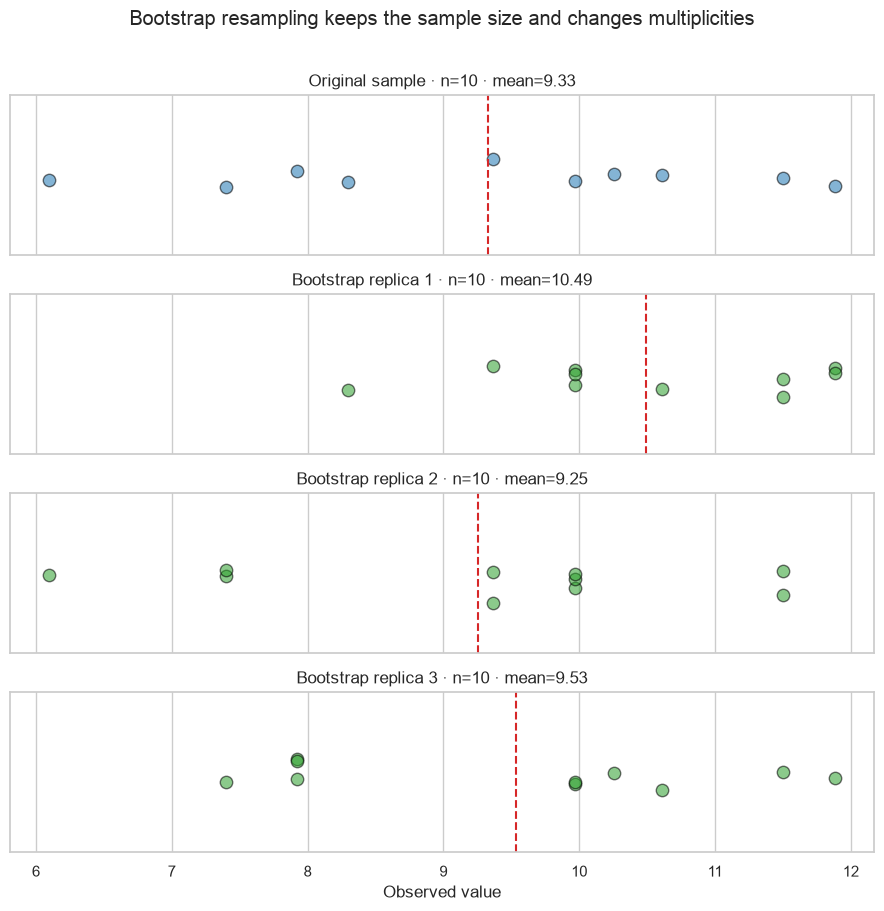

In [2]:
rng = np.random.default_rng(42)
original_sample = pd.DataFrame(
    {"row_id": np.arange(10), "value": rng.normal(loc=10, scale=2, size=10)}
)
example_samples = [original_sample] + [
    sample(original_sample, seed=seed, order_by="row_id") for seed in (1, 2, 3)
]
sample_titles = [
    "Original sample",
    "Bootstrap replica 1",
    "Bootstrap replica 2",
    "Bootstrap replica 3",
]
colors = ["tab:blue", "tab:green", "tab:green", "tab:green"]
jitter_rng = np.random.default_rng(7)

fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True)
for axis, frame, title, color in zip(axes, example_samples, sample_titles, colors):
    mean = frame["value"].mean()
    axis.scatter(
        frame["value"],
        jitter_rng.normal(0, 0.012, len(frame)),
        s=80,
        alpha=0.55,
        color=color,
        edgecolor="black",
    )
    axis.axvline(mean, color="tab:red", linestyle="--", linewidth=1.5)
    axis.set_title(f"{title} · n={len(frame)} · mean={mean:.2f}")
    axis.set_yticks([])
    axis.set_ylim(-0.08, 0.08)
axes[-1].set_xlabel("Observed value")
fig.suptitle("Bootstrap resampling keeps the sample size and changes multiplicities", y=1.01)
fig.tight_layout()
plt.show()

### From replicas to a percentile interval

The distribution of a statistic across replicas gives a percentile interval. Here the 2.5th and 97.5th percentiles form a 95% interval for the sample mean.

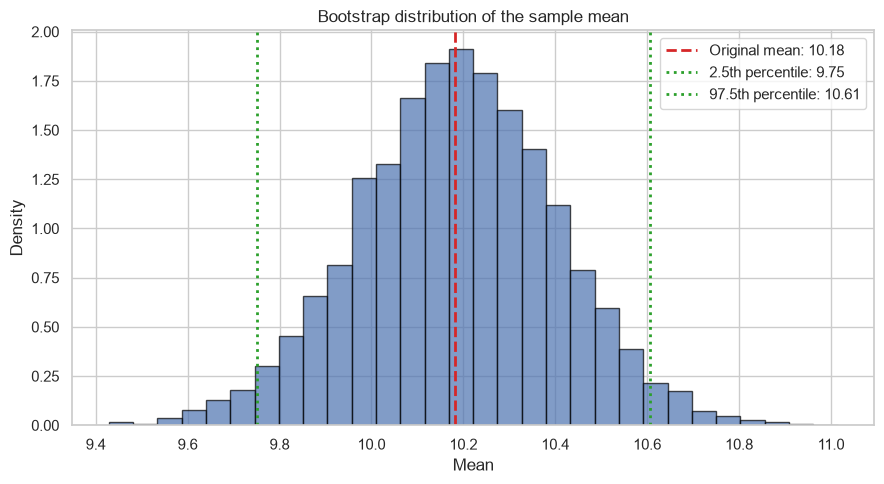

point estimate   10.182
95% lower         9.752
95% upper        10.606
dtype: float64

In [3]:
rng = np.random.default_rng(42)
mean_sample = pd.DataFrame({"row_id": np.arange(50), "value": rng.normal(loc=10, scale=2, size=50)})
mean_replicas = bootstrap(
    mean_sample,
    n_replicas=5_000,
    seed=42,
    order_by="row_id",
)
sample_means = mean_replicas.groupby("replica")["value"].mean()
original_mean = sample_means.loc[-1]
bootstrap_means = sample_means.loc[sample_means.index >= 0]
lower, upper = bootstrap_means.quantile([0.025, 0.975])

fig, axis = plt.subplots(figsize=(9, 5))
axis.hist(bootstrap_means, bins=30, density=True, alpha=0.7, edgecolor="black")
axis.axvline(
    original_mean,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label=f"Original mean: {original_mean:.2f}",
)
axis.axvline(
    lower, color="tab:green", linestyle=":", linewidth=2, label=f"2.5th percentile: {lower:.2f}"
)
axis.axvline(
    upper, color="tab:green", linestyle=":", linewidth=2, label=f"97.5th percentile: {upper:.2f}"
)
axis.set_title("Bootstrap distribution of the sample mean")
axis.set_xlabel("Mean")
axis.set_ylabel("Density")
axis.legend()
fig.tight_layout()
plt.show()

pd.Series({"point estimate": original_mean, "95% lower": lower, "95% upper": upper})

## Setup for precision–recall plots

The educational examples above use the pandas backend. The same `sample()`, `bootstrap()`, `confusion_table()`, `calculate_pr()`, and `at()` calls accept Polars or Spark frames and preserve their native frame type. The PR plotting helper currently performs its grouped interval aggregation in Spark, so the worked PR example starts a small local session.

In [4]:
from pyspark.sql import SparkSession

os.environ["PYSPARK_PYTHON"] = sys.executable
spark = (
    SparkSession.builder.master("local[2]")
    .appName("replicas-reference-example")
    .config("spark.ui.enabled", "false")
    .config("spark.ui.showConsoleProgress", "false")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/08 23:20:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## The bootstrap functions

Everything downstream is a calculation grouped by `replica` and whatever model or cohort columns matter.

### `sample()`—one resample

`sample()` draws rows with replacement, optionally within strata. Stratification matters under class imbalance: a rare-class replica can otherwise contain no positives, making a metric undefined. The earlier four-panel figure called this package function directly.

A supplied `seed` makes draws reproducible. `seed=None` creates a fresh run seed. Seeded Spark sampling also needs an `order_by` key that uniquely orders rows within every stratum.

### `bootstrap()`—many replicas, materialized once

`bootstrap()` returns one long dataframe with the original columns plus `replica`. Replica `-1` is the un-resampled data; replicas `0` through `n_replicas - 1` are independent draws. On Spark, the package checkpoints the result eagerly, so repeated actions reuse the same rows.

## Demo: precision–recall curves with confidence bands

Bootstrap is generic: it gives you replicas, and you decide what to calculate. Precision–recall is useful here because both the operating-point distribution and the full uncertainty band are informative.

### Data conventions

The prediction table uses four metric columns:

- `prediction`: a score where larger means more likely positive;
- `positive`: verified positive;
- `negative`: verified negative;
- `unlabeled`: prediction exists but the label is not verified.

The three label indicators are mutually exclusive. Unlabeled rows are counted separately as `UP`; they are not silently treated as negatives. The same convention can be applied one-vs-rest for multiclass evaluation.

### Exact reference toy data

The tied scores are deliberate: bootstrap duplicates produce ties, and `confusion_table()` must collapse them before cumulative counts are calculated.

In [5]:
toy_data = [
    (0.98, 0, 1, 0, "model"),
    (0.97, 0, 1, 0, "model"),
    (0.96, 1, 0, 0, "model"),
    (0.95, 0, 1, 0, "model"),
    (0.95, 0, 1, 0, "model"),
    (0.94, 1, 0, 0, "model"),
    (0.93, 0, 1, 0, "model"),
    (0.92, 0, 1, 0, "model"),
    (0.91, 0, 1, 0, "model"),
    (0.90, 0, 1, 0, "model"),
    (0.88, 0, 1, 0, "model"),
    (0.86, 0, 0, 1, "model"),
    (0.75, 1, 0, 0, "model"),
    (0.73, 0, 1, 0, "model"),
    (0.55, 1, 0, 0, "model"),
    (0.53, 1, 0, 0, "model"),
    (0.41, 1, 0, 0, "model"),
    (0.36, 1, 0, 0, "model"),
    (0.36, 1, 0, 0, "model"),
    (0.36, 1, 0, 0, "model"),
    (0.21, 1, 0, 0, "model"),
    (0.16, 1, 0, 0, "model"),
    (0.10, 0, 1, 0, "model"),
    (0.09, 0, 1, 0, "model"),
    (0.06, 1, 0, 0, "model"),
]
toy = pd.DataFrame(
    toy_data,
    columns=["prediction", "negative", "positive", "unlabeled", "name"],
)
toy["row_id"] = np.arange(len(toy))
toy_df = spark.createDataFrame(toy)
toy.head()

,prediction,negative,positive,unlabeled,name,row_id
0,0.980,0,1,0,model,0
1,0.970,0,1,0,model,1
2,0.960,1,0,0,model,2
3,0.950,0,1,0,model,3
4,0.950,0,1,0,model,4


### Confusion counts at every threshold

`confusion_table()` sweeps every prediction score as a threshold. `TP`, `FP`, and `UP` are cumulative counts above the threshold; `dTP`, `dFP`, and `dUP` count rows exactly at that score. Scores are collapsed before cumulative counts are calculated because bootstrap resampling creates many ties.

The row at threshold `0.95` has `dTP=2`, proving the tie was handled as one threshold. Every row retains totals of 12 positives, 12 negatives, and one unlabeled prediction.

In [6]:
toy_ct = confusion_table(toy_df, by=["name"])
toy_ct.toPandas().sort_values("threshold", ascending=False).round(2)

,name,threshold,TP,FP,UP,dTP,dFP,dUP,positives,negatives,unlabeled
0,model,0.980,1,0,0,1,0,0,12,12,1
1,model,0.970,2,0,0,1,0,0,12,12,1
2,model,0.960,2,1,0,0,1,0,12,12,1
3,model,0.950,4,1,0,2,0,0,12,12,1
4,model,0.940,4,2,0,0,1,0,12,12,1
5,model,0.930,5,2,0,1,0,0,12,12,1
6,model,0.920,6,2,0,1,0,0,12,12,1
7,model,0.910,7,2,0,1,0,0,12,12,1
8,model,0.900,8,2,0,1,0,0,12,12,1
9,model,0.880,9,2,0,1,0,0,12,12,1


### Precision, recall, and running average precision

`calculate_pr()` derives precision and recall from the confusion table and keeps thresholds where `dTP > 0`, because other thresholds do not advance recall. `average_precision` is a running value; its complete value is on the last, lowest-threshold retained row.

In [7]:
toy_kpi = calculate_pr(toy_ct, by=["name"])
(
    toy_kpi.select(
        "name",
        "threshold",
        "TP",
        "FP",
        "UP",
        "precision",
        "recall",
        "average_precision",
    )
    .toPandas()
    .sort_values("threshold", ascending=False)
    .round(3)
)

,name,threshold,TP,FP,UP,precision,recall,average_precision
0,model,0.980,1,0,0,1.000,0.083,1.000
1,model,0.970,2,0,0,1.000,0.167,1.000
2,model,0.950,4,1,0,0.800,0.333,0.900
3,model,0.930,5,2,0,0.714,0.417,0.863
4,model,0.920,6,2,0,0.750,0.500,0.844
5,model,0.910,7,2,0,0.778,0.583,0.835
6,model,0.900,8,2,0,0.800,0.667,0.830
7,model,0.880,9,2,0,0.818,0.750,0.829
8,model,0.730,10,3,1,0.769,0.833,0.823
9,model,0.100,11,11,1,0.500,0.917,0.794


### Point estimate at 81% precision

`at()` picks a deployable operating point independently for each group. It returns the numerically smallest threshold satisfying its one condition; groups with no qualifying row are absent.

The target `0.81` is deliberate. Precision is `0.800` at threshold `0.90` and `0.818` at `0.88`; precision is not monotonic, so the selected threshold is `0.88`.

In [8]:
at(toy_kpi, by=["name"], precision=0.81).toPandas().round(3)

,name,threshold,TP,FP,UP,dTP,dFP,dUP,positives,negatives,unlabeled,precision,recall,average_precision
0,model,0.880,9,2,0,1,0,0,12,12,1,0.818,0.750,0.829


### The same metrics over 100 bootstrap replicas

The same calculation now runs over 100 resamples. Sampling is stratified by model and positive label so every replica preserves each class size. The package resolves one run seed and derives independent streams for each stratum and replica; `order_by` gives Spark stable row positions.

In [9]:
bts_toy_df = bootstrap(
    toy_df,
    by=["name", "positive"],
    n_replicas=100,
    seed=42,
    order_by="row_id",
)
toy_ct = confusion_table(bts_toy_df, by=["name", "replica"])
toy_kpi = calculate_pr(toy_ct, by=["name", "replica"])
toy_th = at(
    toy_kpi,
    by=["name", "replica"],
    precision=0.81,
).toPandas()

#### Operating-point uncertainty at 81% precision

`box_plot()` accepts the pandas result of `at(...).toPandas()` and shows how the selected threshold and its metrics move across replicas. With no `row`, `col`, or `hue`, this reference call produces one plot. `(0, 100)` draws whiskers to the observed range.

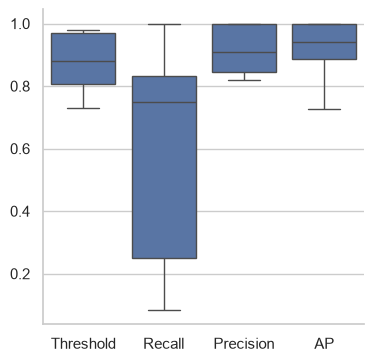

In [10]:
box_plot(toy_th, whis=(0, 100), height=4)

#### Full PR uncertainty on the toy data

`plot_pr()` handles grouping and confidence intervals in one command. With no `row`, `col`, or `hue`, this reference call produces one PR plot. Replica `-1` supplies the central curve; the default 90% pointwise band uses the 5th and 95th percentiles of bootstrap precision at each rounded recall value.

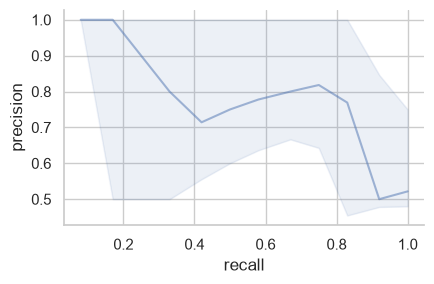

In [11]:
plot_pr(toy_kpi, aspect=1.5, recall_round=2)

## A realistic example: rare positives and two models

Toy data is too small to show what bootstrap is really for. The reference notebook downloads a credit-card-fraud dataset and trains two CatBoost models. A package example should run anywhere, so this version replaces only that network- and training-dependent setup with deterministic synthetic predictions. It preserves the reference decision problem: rare positives, two competing models, and the question of whether an apparent improvement is larger than evaluation-set noise.

The data below has about a 3% positive rate. `baseline` and `candidate` score the same cases; the `name` column stacks both prediction sets into the long format used throughout the reference design.

In [12]:
rng = np.random.default_rng(2026)
n_rows = 8_000
row_id = np.arange(n_rows)
period = rng.choice(["earlier", "recent"], n_rows)
segment = rng.choice(["new", "returning"], n_rows)
prevalence_logit = -3.75 + 0.35 * (segment == "returning") + 0.20 * (period == "recent")
positive = rng.random(n_rows) < 1 / (1 + np.exp(-prevalence_logit))
shared = rng.normal(size=n_rows)
baseline_logit = (
    -3.5
    + 3.6 * positive
    + 0.55 * shared
    + rng.normal(size=n_rows)
    - 0.20 * (positive & (segment == "new"))
    - 0.20 * (positive & (period == "recent"))
)
candidate_logit = (
    -3.6
    + 3.9 * positive
    + 0.55 * shared
    + 0.90 * rng.normal(size=n_rows)
    - 0.15 * (positive & (segment == "new"))
    - 0.10 * (positive & (period == "recent"))
)
baseline = 1 / (1 + np.exp(-baseline_logit))
candidate = 1 / (1 + np.exp(-candidate_logit))

labels = pd.DataFrame(
    {
        "row_id": row_id,
        "period": period,
        "segment": segment,
        "positive": positive.astype("int32"),
        "negative": (~positive).astype("int32"),
        "unlabeled": np.zeros(n_rows, dtype="int32"),
    }
)
predictions = pd.concat(
    [
        labels.assign(name="baseline", prediction=baseline),
        labels.assign(name="candidate", prediction=candidate),
    ],
    ignore_index=True,
)[
    [
        "row_id",
        "period",
        "segment",
        "name",
        "prediction",
        "positive",
        "negative",
        "unlabeled",
    ]
]
predictions_df = spark.createDataFrame(predictions)
predictions.groupby("name").agg(rows=("row_id", "size"), positives=("positive", "sum"))

,rows,positives
name,,
baseline,8000,226
candidate,8000,226


### Bootstrap and calculate both models in one pass

In [13]:
bts = bootstrap(
    predictions_df,
    by=["name", "positive"],
    n_replicas=100,
    seed=42,
    order_by="row_id",
)
groups = ["name", "replica"]
ct = confusion_table(bts, by=groups)
kpi = calculate_pr(ct, by=groups)

### Model operating points at 95% precision

`at()` applies the same selection rule independently to each model and replica.

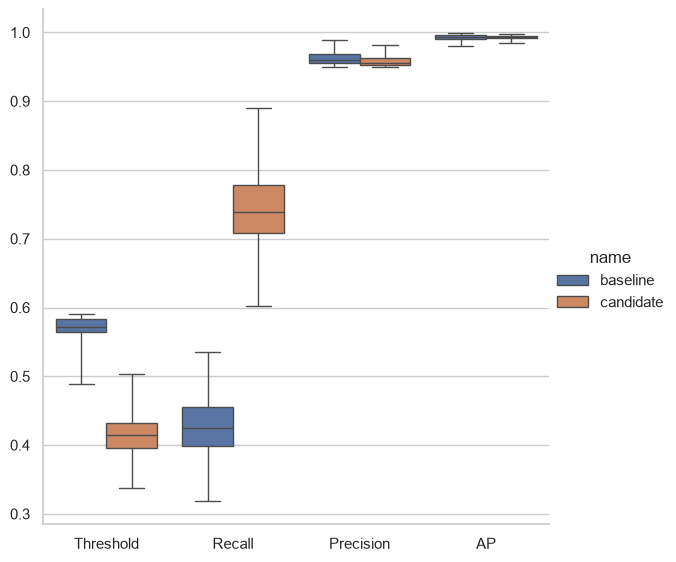

In [14]:
ops = at(kpi, by=groups, precision=0.95).toPandas()
box_plot(ops, hue="name", whis=(0, 100), height=6)

### Two PR curves with pointwise uncertainty bands

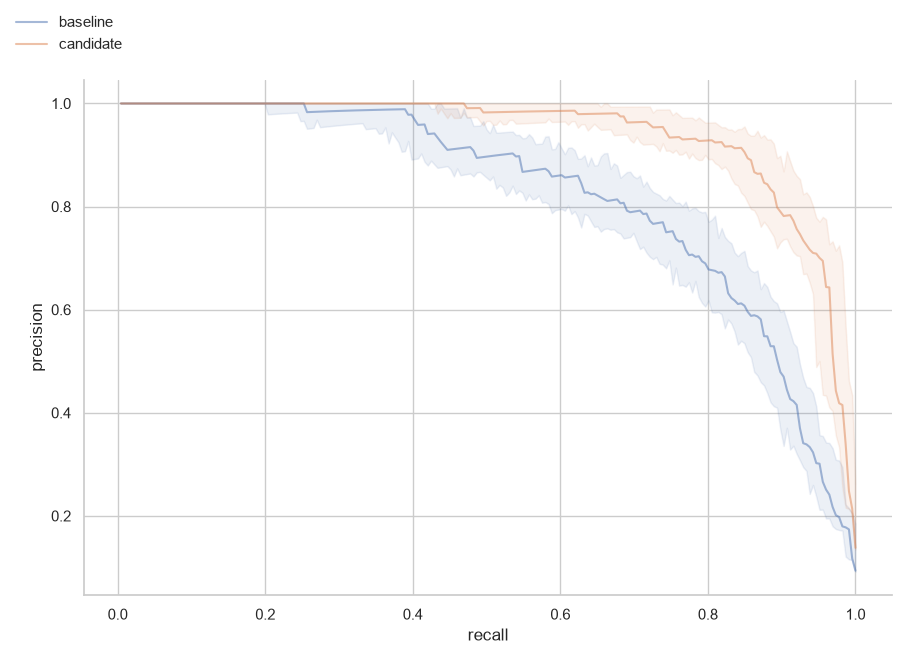

In [15]:
plot_pr(kpi, hue="name", aspect=1.5, height=6)

### Reading the comparison

The operating-point boxes answer how much the selected threshold and achieved metrics move. The PR bands show where uncertainty is concentrated along the full trade-off. They are pointwise percentile bands, not simultaneous confidence regions, and overlap alone is not a formal test of a model difference.

## PR curves inside cohort groups

`plot_pr()` uses `row`, `col`, and `hue` as aggregation keys as well as visual mappings. Here periods are rows, segments are columns, and models are hues. `recall_round=2` aligns the smaller cohort-level recall grids.

In [16]:
facet_groups = ["period", "segment", "name", "replica"]
facet_ct = confusion_table(bts, by=facet_groups)
facet_kpi = calculate_pr(facet_ct, by=facet_groups)

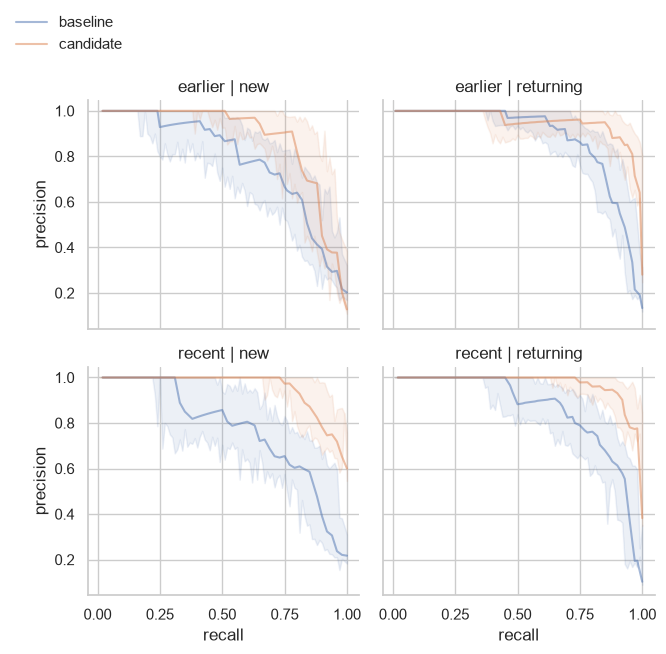

In [17]:
plot_pr(
    facet_kpi,
    row="period",
    col="segment",
    hue="name",
    recall_round=2,
    height=3,
    aspect=1.1,
)

## Beyond PR: any statistic by replica

The bootstrap output is generic: any calculation by `replica` becomes a distribution. The reference used an AUC evaluator loop, but that launches one Spark evaluation per model and replica and obscures the pattern. Brier score demonstrates the same idea with one transparent aggregation and no extra dependency: calculate squared error for each row, aggregate by model and replica, then summarize. Lower is better.

In [18]:
brier_rows = bts.select("name", "replica", "prediction", "positive").toPandas()
brier_rows["squared_error"] = (brier_rows["prediction"] - brier_rows["positive"]) ** 2
brier = (
    brier_rows.groupby(["name", "replica"], as_index=False)["squared_error"]
    .mean()
    .rename(columns={"squared_error": "brier"})
)
point_brier = brier[brier["replica"] == -1].set_index("name")["brier"]
bootstrap_brier = brier[brier["replica"] >= 0]
brier_summary = bootstrap_brier.groupby("name")["brier"].agg(
    p05=lambda values: values.quantile(0.05),
    median="median",
    p95=lambda values: values.quantile(0.95),
)
brier_summary.insert(0, "point estimate", point_brier)
brier_summary.round(4)

,point estimate,p05,median,p95
name,,,,
baseline,0.014,0.013,0.014,0.015
candidate,0.011,0.010,0.011,0.011


## Summary

1. **Single numbers hide sampling variation.** Bootstrap turns that hidden variation into distributions and bands.
2. **Replicas need a stable identity.** Replica `-1` preserves the observed estimate; replicas `0+` are reproducible resamples when a seed is supplied, and Spark materializes them once.
3. **The pattern generalizes.** Replicas in, metrics out. The same library workflow supports operating points, full curves, cohort facets, and arbitrary statistics on pandas, Polars, or Spark.

Confidence intervals still describe only the chosen resampling design and observed data; they do not correct dataset bias.

In [19]:
spark.stop()